In [155]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns

gender_path = Path('2014-2023_Index_World_economic_forum.xlsx')
gender_data = pd.read_excel(gender_path)
gender_data.head(3)

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Iceland,0.8594,0.881,0.874,0.878,0.858,NaN,0.877,0.892,0.908,0.912
1,Norway,0.8374,0.850,0.842,0.830,0.835,NaN,0.842,0.849,0.845,0.879
2,Sweden,0.8165,0.823,0.815,0.816,0.822,NaN,0.820,0.823,0.822,0.815


In [156]:
northern_country = ['Denmark', 'Estonia', 'Finland', 'Iceland', 'Ireland', 'Lituania', 'Norway', 'Sweden', 'Uk']
southern_country = ['Albany', 'bosnia', 'Croatia', 'Cyprus', 'Greece', 'Italy', 'Malta', 'Montenegro', 'Portugal', 'Serbia', 'Slovenia', 'Spain', 'Macedonia']
western_country = ['Austria', 'Belgium', 'France', 'Germany', 'Louxemburg', 'Netherland', 'Switzerland']
eastern_country = ['Czech Rep.', 'slovakia', 'Ukrain', 'Poland', 'Hungary', 'Moldova', 'Bulgary', 'Romania']

In [157]:
# Filling the missing value for 2019 with the average of 2018 and 2020
year_cols = [c for c in gender_data.columns if c != 'Country']
gender_data[year_cols] = gender_data[year_cols].astype(float)
gender_data[2019] = (gender_data[2018] + gender_data[2020]) / 2
years = gender_data.index

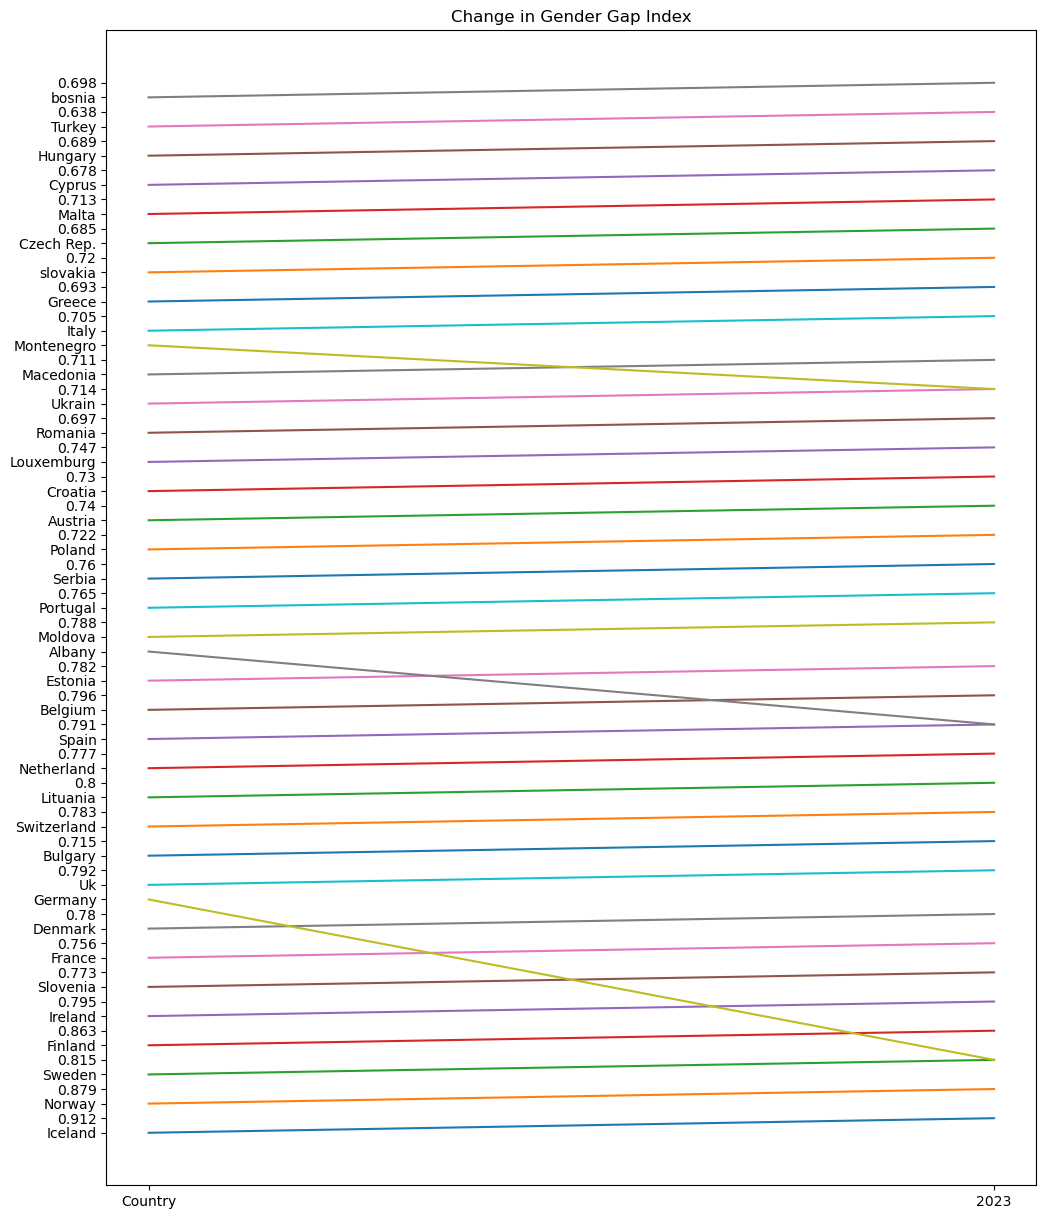

In [158]:
start = gender_data.columns[0]
end = gender_data.columns[-1]

plt.figure(figsize=(12,15))

for country in gender_data.index:
    plt.plot([0,1], [gender_data.loc[country, start], gender_data.loc[country, end]])

plt.xticks([0,1], [start, end])
plt.title("Change in Gender Gap Index")
plt.show()

In [159]:
#remove index column on x axis and transpose the data frame to have years as columns and countries as rows
gender_data = gender_data.set_index('Country').T
gender_data.head(3)

Country,Iceland,Norway,Sweden,Finland,Ireland,Slovenia,France,Denmark,Germany,Uk,...,Montenegro,Italy,Greece,slovakia,Czech Rep.,Malta,Cyprus,Hungary,Turkey,bosnia
2014,0.8594,0.8374,0.8165,0.8453,0.785,0.7443,0.7588,0.8025,0.778,0.7383,...,0.6934,0.6973,0.6784,0.6806,0.6737,0.6707,0.6741,0.6759,0.6183,NaN
2015,0.8810,0.8500,0.8230,0.8500,0.807,0.7840,0.7610,0.7670,0.779,0.7580,...,0.6890,0.7260,0.6850,0.6750,0.6870,0.6680,0.6710,0.6720,0.6240,NaN
2016,0.8740,0.8420,0.8150,0.8450,0.797,0.7860,0.7550,0.7540,0.766,0.7520,...,0.6810,0.7190,0.6800,0.6790,0.6900,0.6640,0.6840,0.6690,0.6230,0.685


In [160]:
# Add a column with the European average for each year
gender_data['European Average'] = gender_data.mean(axis=1)
gender_data.head(3)

Country,Iceland,Norway,Sweden,Finland,Ireland,Slovenia,France,Denmark,Germany,Uk,...,Italy,Greece,slovakia,Czech Rep.,Malta,Cyprus,Hungary,Turkey,bosnia,European Average
2014,0.8594,0.8374,0.8165,0.8453,0.785,0.7443,0.7588,0.8025,0.778,0.7383,...,0.6973,0.6784,0.6806,0.6737,0.6707,0.6741,0.6759,0.6183,NaN,0.732089
2015,0.8810,0.8500,0.8230,0.8500,0.807,0.7840,0.7610,0.7670,0.779,0.7580,...,0.7260,0.6850,0.6750,0.6870,0.6680,0.6710,0.6720,0.6240,NaN,0.738054
2016,0.8740,0.8420,0.8150,0.8450,0.797,0.7860,0.7550,0.7540,0.766,0.7520,...,0.7190,0.6800,0.6790,0.6900,0.6640,0.6840,0.6690,0.6230,0.685,0.733079


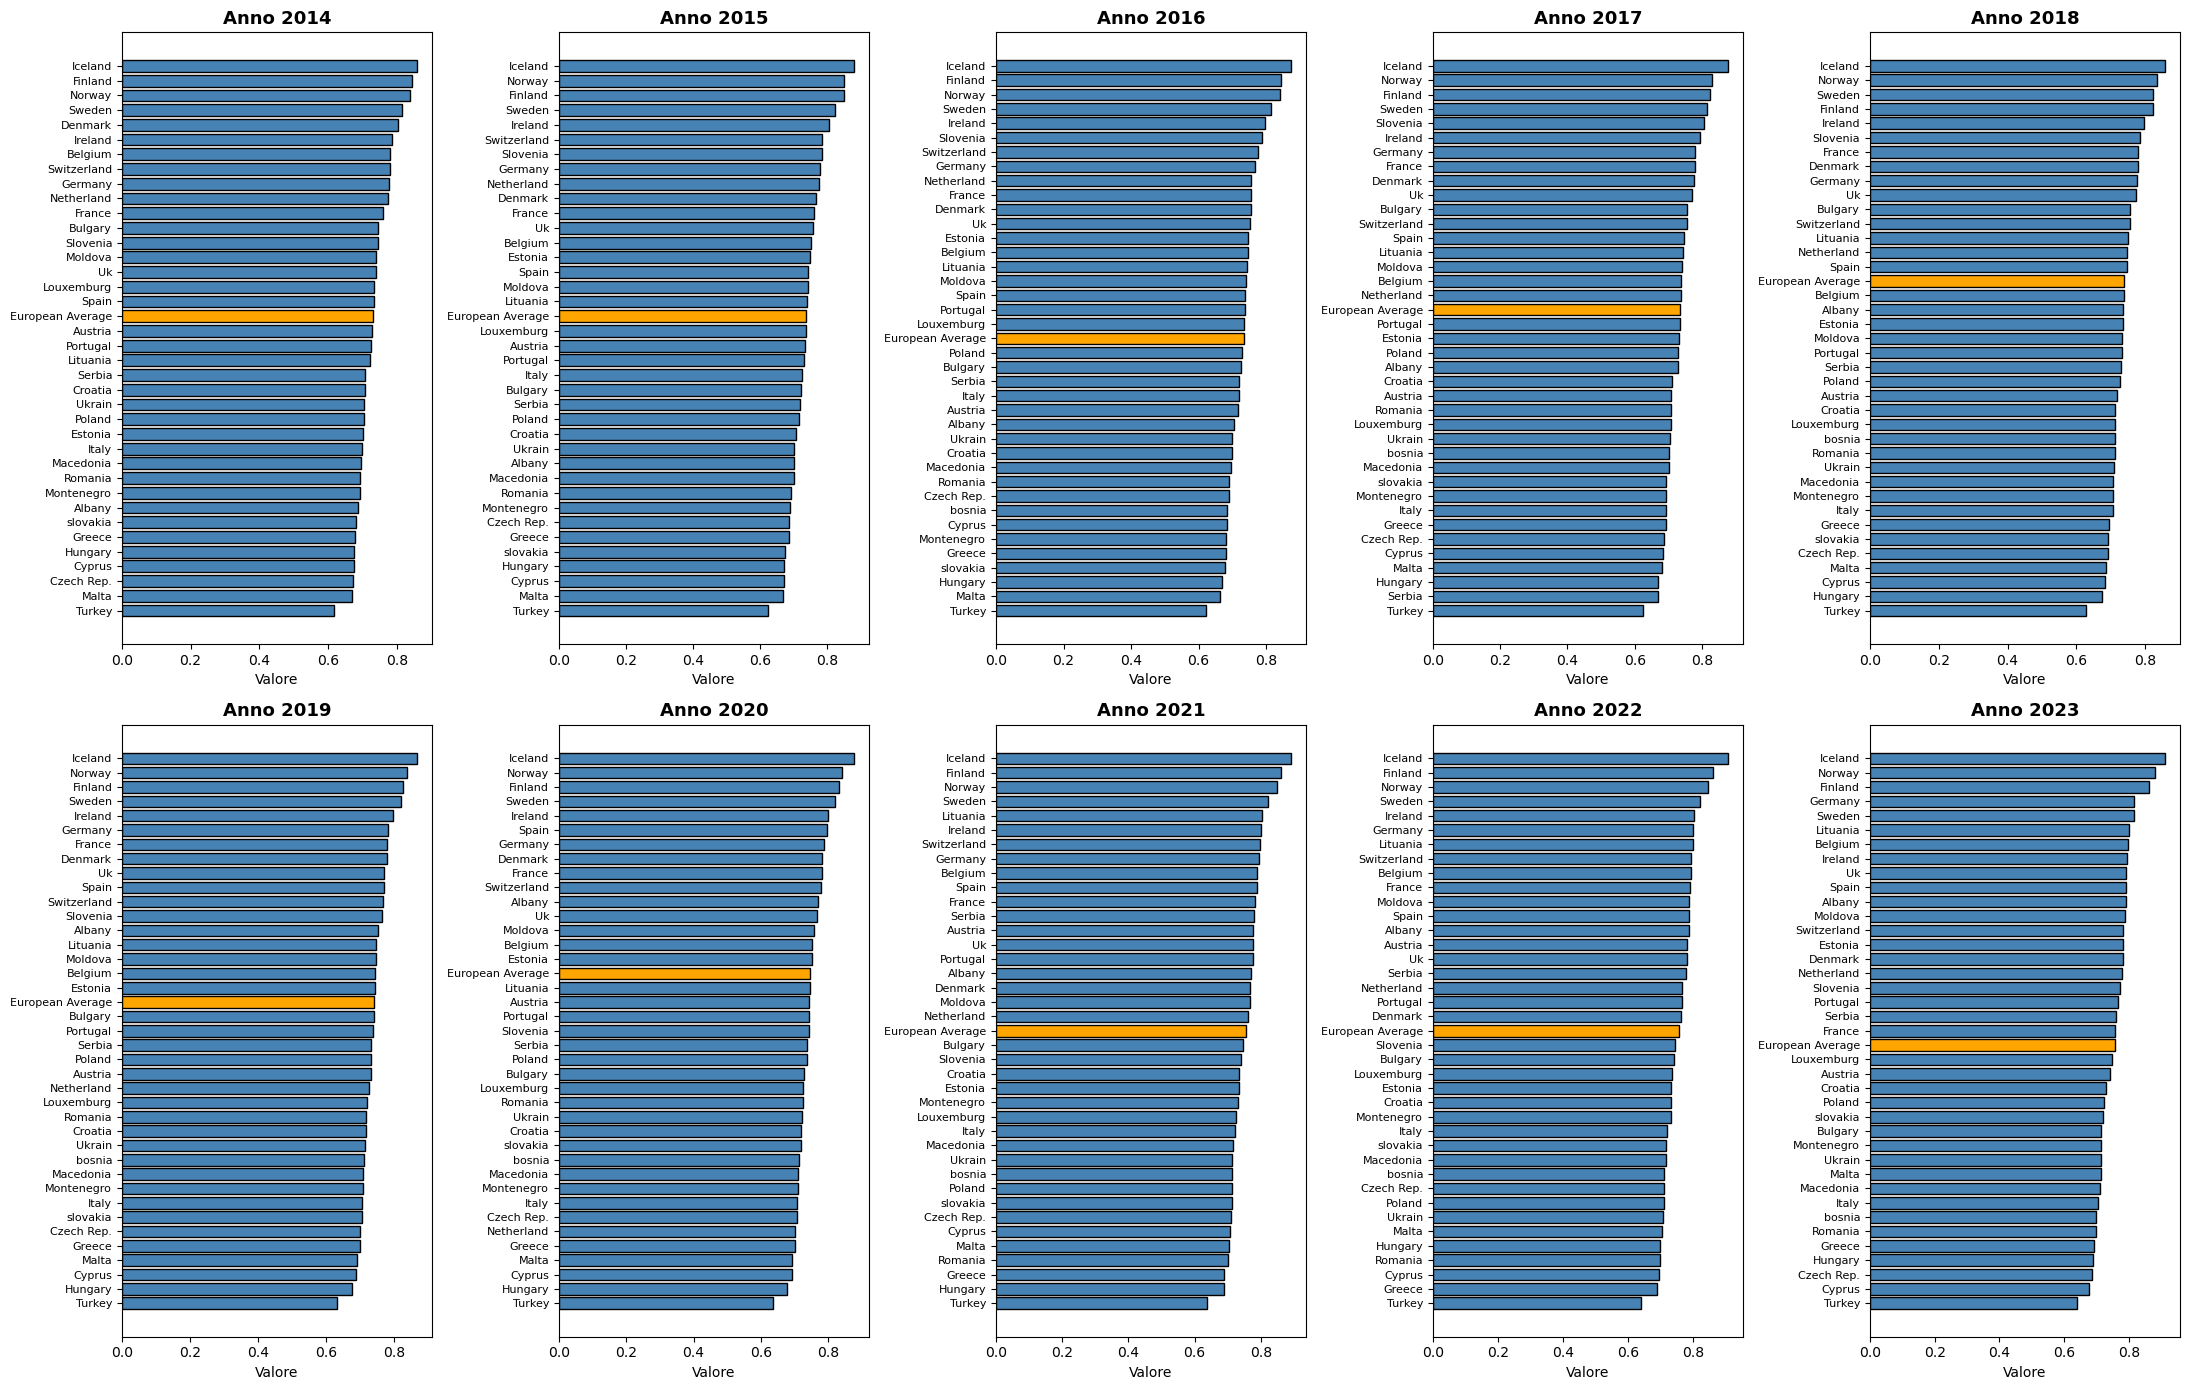

In [161]:
fig, axes = plt.subplots(2, 5, figsize=(22, 14))
axes = axes.flatten()

for i, year in enumerate(year_cols):
    ax = axes[i]
    # Ordina dal maggiore al minore ed elimina eventuali NaN
    serie = gender_data.loc[year].dropna().sort_values(ascending=True)

    ax.barh(serie.index, serie.values, color="steelblue", edgecolor="black")
    ax.set_title(f"Anno {year}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Valore")
    ax.tick_params(axis="y", labelsize=8)
    
    if 'European Average' in serie.index:
        avg_index = serie.index.get_loc('European Average')
        ax.patches[avg_index].set_facecolor("orange")

plt.tight_layout()
plt.show()

In [ ]:
# 4 stacked area plots: EU mean + regional means (N, S, W, E)
years = gender_data.index
available_northern = [c for c in northern_country if c in gender_data.columns]
available_southern = [c for c in southern_country if c in gender_data.columns]
available_western  = [c for c in western_country  if c in gender_data.columns]
available_eastern  = [c for c in eastern_country  if c in gender_data.columns]

regions = {
    'Northern': (available_northern, 'royalblue'),
    'Southern': (available_southern, 'tomato'),
    'Western':  (available_western,  'forestgreen'),
    'Eastern':  (available_eastern,  'mediumpurple'),
}

fig, ax = plt.subplots(figsize=(14, 8))

# EU mean — linea nera in grassetto come riferimento
ax.plot(years, gender_data['European Average'],
        label='EU Mean', color='black', linewidth=3, zorder=5)

# Linee regionali (solo la media)
for region_name, (countries, color) in regions.items():
    if not countries:
        continue
    mean = gender_data[countries].mean(axis=1)
    ax.plot(years, mean, label=f'{region_name} Mean',
            color=color, linewidth=2, marker='.', markersize=5)

ax.set_title('Gender Gap Index Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Gender Gap Index', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# 4 area plots: EU mean + regional means (N, S, W, E)
available_northern = [c for c in northern_country if c in gender_data.columns]
available_southern = [c for c in southern_country if c in gender_data.columns]
available_western  = [c for c in western_country  if c in gender_data.columns]
available_eastern  = [c for c in eastern_country  if c in gender_data.columns]

years = gender_data.index.astype(float)
eu_mean = gender_data['European Average']

regions = {
    'Northern': (available_northern, 'royalblue'),
    'Southern': (available_southern, 'tomato'),
    'Western':  (available_western,  'forestgreen'),
    'Eastern':  (available_eastern,  'mediumpurple'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()

# Asse y comune: parte poco sotto il minimo per far risaltare l'area
all_means = [gender_data[c].mean(axis=1) for c, _ in regions.values() if c]
ymin = min(min(m.min() for m in all_means), eu_mean.min()) - 0.02
ymax = max(max(m.max() for m in all_means), eu_mean.max()) + 0.02

for ax, (region_name, (countries, color)) in zip(axes, regions.items()):
    if not countries:
        ax.set_visible(False)
        continue
    mean = gender_data[countries].mean(axis=1)

    # Area plot della media regionale
    ax.fill_between(years, ymin, mean, color=color, alpha=0.35)
    ax.plot(years, mean, color=color, linewidth=2.5, label=f'{region_name} Mean')

    # EU mean sovrapposto come riferimento
    ax.plot(years, eu_mean, color='black', linewidth=2,
            linestyle='--', label='EU Mean')

    ax.set_title(f'{region_name} Europe', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Gender Gap Index')
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='lower right')

fig.suptitle('Gender Gap Index Over Time — Regional Area Plots',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
start_year = 2014
end_year = 2023

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (region, (countries, color)) in zip(axes, regions.items()):

    available = [c for c in countries if c in gender_data.columns]

    if len(available) == 0:
        ax.set_visible(False)
        continue

    country_means = gender_data[available].mean(axis=0).sort_values(ascending=False)

    ax.bar(
        country_means.index,
        country_means.values,
        color=color
    )

    ax.set_title(f"{region} ({start_year}-{end_year})")
    ax.set_xlabel("Country")
    ax.set_ylabel("Mean Index")
    ax.set_ylim(0.6, 0.95)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Average Gender Gap Index by Region ({start_year}-{end_year})", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# 4 subplots — un paese per tacca sull'asse x, media 2014-2023 in y
regions_def = {
    'Northern': (available_northern, 'royalblue'),
    'Southern': (available_southern, 'tomato'),
    'Western':  (available_western,  'forestgreen'),
    'Eastern':  (available_eastern,  'mediumpurple'),
}

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

eu_avg = gender_data['European Average'].mean()

for ax, (region, (countries, color)) in zip(axes, regions_def.items()):
    available = [c for c in countries if c in gender_data.columns]
    if not available:
        ax.set_visible(False)
        continue

    values = gender_data[available].mean(axis=0).sort_values(ascending=False)

    bars = ax.bar(values.index, values.values, color=color, edgecolor='white', linewidth=0.6)

    for bar, val in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

    ax.axhline(eu_avg, color='black', linewidth=1.4, linestyle='--', label=f'EU avg ({eu_avg:.3f})')

    ax.set_title(f'{region} Europe — Media 2014-2023', fontsize=13, fontweight='bold')
    ax.set_xlabel('Country', fontsize=11)
    ax.set_ylabel('Gender Gap Index (media 10 anni)', fontsize=11)
    ax.set_ylim(0.60, 0.95)
    ax.tick_params(axis='x', rotation=40, labelsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('Gender Gap Index per Paese e Regione — Media 2014-2023',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
